# Move Type Classification Algorithm Exploration

**Objective**: Develop database-driven logic to classify career moves as up/down/sideways/technical/leadership transitions using JobFunction and ManagementLevel data.

**Database Schema Reference**:
- `jobs` table: JobProfileID, JobFunction, ManagementLevel, JobCategory
- `career_pathways` table: source_job_id, target_job_id, similarity_score
- `positions` table: JobProfileID, Division, Business_Unit

**Key Challenge**: Replace manual classification with automated logic based on actual database fields.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up database connection
db_path = Path(r"C:\Users\kipjo\OneDrive\Documents\GitHub\skill-similarity-engine\models\2025-Q2\business_context.sqlite")
print(f"Database path: {db_path}")
print(f"Database exists: {db_path.exists()}")

# Connect to database
conn = sqlite3.connect(db_path)
print("✅ Connected to database")

Database path: C:\Users\kipjo\OneDrive\Documents\GitHub\skill-similarity-engine\models\2025-Q2\business_context.sqlite
Database exists: True
✅ Connected to database


## 1. Explore Job Architecture Data

First, let's understand the structure of JobFunction and ManagementLevel data that we'll use for classification.


In [5]:
# Explore jobs table structure
jobs_query = """
SELECT JobProfileID, JobProfile, JobFunction, ManagementLevel, JobCategory,
       Customer_Facing, is_Banker, Executive_Leadership_Group
FROM jobs 
LIMIT 10
"""

jobs_sample = pd.read_sql_query(jobs_query, conn)
print("📋 Sample Jobs Data:")
display(jobs_sample)

print("\n📊 Jobs Table Statistics:")
print(f"Total jobs: {pd.read_sql_query('SELECT COUNT(*) as count FROM jobs', conn)['count'][0]}")

# Analyze ManagementLevel distribution and unique values
management_levels = pd.read_sql_query("""
SELECT ManagementLevel, COUNT(*) as count
FROM jobs 
WHERE ManagementLevel IS NOT NULL
GROUP BY ManagementLevel 
ORDER BY ManagementLevel
""", conn)

print("\n🎯 ManagementLevel Distribution:")
display(management_levels)

print("\n📝 Unique ManagementLevel Values:")
unique_levels = pd.read_sql_query("""
SELECT DISTINCT ManagementLevel
FROM jobs 
WHERE ManagementLevel IS NOT NULL
ORDER BY ManagementLevel
""", conn)['ManagementLevel'].tolist()
print(f"Levels found: {unique_levels}")
print(f"Total unique levels: {len(unique_levels)}")


📋 Sample Jobs Data:


,JobProfileID,JobProfile,JobFunction,ManagementLevel,JobCategory,Customer_Facing,is_Banker,Executive_Leadership_Group
0,R0001.5,Payment Systems Analyst - 5,Data & Analytics,Group 2,Support,Customer Facing,Non-Banker,
1,R0001.6,Settlement Officer - 6,Data & Analytics,Group 1,Support,Customer Facing,Banker,Executive Leadership Group
2,R0002.0,Sales Manager - II,Banking Services,Group 4,Enabling,Customer Facing,Banker,
3,R0002.1,Sales Manager - 1,Security & Fraud,Group 2,Revenue Generating,Customer Facing,Banker,
4,R0002.2,Relationship Manager - 2,Investment Management,Group 3,Enabling,Customer Facing,Banker,
5,R0002.3,Customer Service Representative - 3,Facilities & Administration,Group 3,Revenue Generating,Non-Customer Facing,Banker,
6,R0002.4,Customer Service Representative - 4,Security & Fraud,Group 3,Revenue Generating,Customer Facing,Banker,
7,R0003.0,Cloud Architect - 0,Data & Analytics,Group 2,Enabling,Customer Facing,Non-Banker,
8,R0003.2,Digital Product Manager - III,Risk Management,Group 6,Enabling,Non-Customer Facing,Non-Banker,
9,R0005.1,Business Banker - 1,Customer Relations,Group 2,Support,Customer Facing,Non-Banker,



📊 Jobs Table Statistics:
Total jobs: 715

🎯 ManagementLevel Distribution:


,ManagementLevel,count
0,Group 1,123
1,Group 2,173
2,Group 3,137
3,Group 4,127
4,Group 5,78
5,Group 6,44
6,Group 7,20
7,Group NA,13



📝 Unique ManagementLevel Values:
Levels found: ['Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group 7', 'Group NA']
Total unique levels: 8


🏢 JobFunction Distribution:


,JobFunction,count
0,Operations & Processing,78
1,Risk Management,55
2,Finance & Treasury,54
3,Facilities & Administration,51
4,Banking Services,45
5,Investment Management,44
6,Data & Analytics,41
7,Technology & Engineering,36
8,Marketing & Communications,35
9,Research & Analysis,33


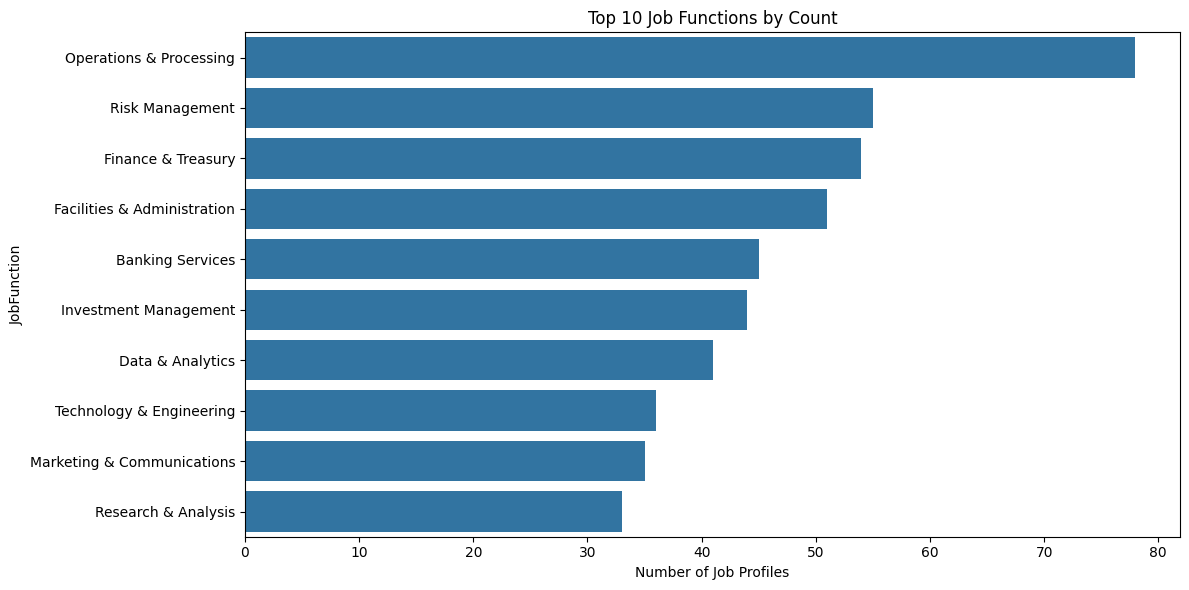

In [3]:
# Analyze JobFunction distribution
job_functions = pd.read_sql_query("""
SELECT JobFunction, COUNT(*) as count
FROM jobs 
WHERE JobFunction IS NOT NULL
GROUP BY JobFunction 
ORDER BY count DESC
""", conn)

print("🏢 JobFunction Distribution:")
display(job_functions)

# Visualize JobFunction distribution
plt.figure(figsize=(12, 6))
sns.barplot(data=job_functions.head(10), x='count', y='JobFunction')
plt.title('Top 10 Job Functions by Count')
plt.xlabel('Number of Job Profiles')
plt.tight_layout()
plt.show()


In [4]:
def classify_move_type(source_function, source_level, target_function, target_level, hierarchy_map):
    """
    Classify career move type based on job function and management level changes.
    
    Returns: tuple (move_type, move_subtype, level_change)
    """
    # Get hierarchy ranks
    source_rank = hierarchy_map.get(source_level, 0)
    target_rank = hierarchy_map.get(target_level, 0)
    level_change = target_rank - source_rank
    
    # Same function vs different function
    same_function = (source_function == target_function)
    
    # Classification logic
    if same_function:
        if level_change > 0:
            return 'progression', 'vertical_up', level_change
        elif level_change < 0:
            return 'regression', 'vertical_down', level_change
        else:
            return 'lateral', 'same_level_same_function', level_change
    else:
        # Different function
        if level_change > 0:
            return 'cross_functional_progression', 'diagonal_up', level_change
        elif level_change < 0:
            return 'cross_functional_regression', 'diagonal_down', level_change
        else:
            return 'lateral', 'cross_functional_lateral', level_change

# Test the classification function
test_cases = [
    ('Data & Analytics', 'Group 2', 'Data & Analytics', 'Group 4'),  # Same function, up
    ('Data & Analytics', 'Group 4', 'Risk Management', 'Group 4'),   # Different function, same level
    ('Banking Services', 'Group 3', 'Executive Leadership', 'Group 6'), # Cross-functional up
    ('Finance & Treasury', 'Group 5', 'Finance & Treasury', 'Group 3'), # Same function, down
]

print("🧪 Testing Move Classification Logic:")
for i, (sf, sl, tf, tl) in enumerate(test_cases):
    move_type, subtype, change = classify_move_type(sf, sl, tf, tl, hierarchy_map)
    print(f"Test {i+1}: {sf} ({sl}) → {tf} ({tl})")
    print(f"  Result: {move_type} | {subtype} | Level change: {change:+d}")
    print()


🧪 Testing Move Classification Logic:


NameError: name 'hierarchy_map' is not defined

In [ ]:
# Create management level hierarchy mapping
def create_management_hierarchy():
    """
    Create a hierarchy mapping for management levels.
    Higher numbers = higher seniority
    """
    hierarchy_map = {
        'Group NA': 0,  # Non-management or unclear
        'Group 1': 1,   # Entry level
        'Group 2': 2,   # Junior
        'Group 3': 3,   # Mid-level
        'Group 4': 4,   # Senior
        'Group 5': 5,   # Principal/Lead
        'Group 6': 6,   # Manager
        'Group 7': 7,   # Senior Manager/Director
    }
    return hierarchy_map

hierarchy_map = create_management_hierarchy()
print("📊 Management Level Hierarchy:")
for level, rank in hierarchy_map.items():
    print(f"  {level}: {rank}")

# Test hierarchy with sample data
test_query = """
SELECT ManagementLevel, COUNT(*) as count,
       AVG(CASE 
           WHEN ManagementLevel = 'Group NA' THEN 0
           WHEN ManagementLevel = 'Group 1' THEN 1
           WHEN ManagementLevel = 'Group 2' THEN 2
           WHEN ManagementLevel = 'Group 3' THEN 3
           WHEN ManagementLevel = 'Group 4' THEN 4
           WHEN ManagementLevel = 'Group 5' THEN 5
           WHEN ManagementLevel = 'Group 6' THEN 6
           WHEN ManagementLevel = 'Group 7' THEN 7
           ELSE 0 END) as hierarchy_rank
FROM jobs 
GROUP BY ManagementLevel 
ORDER BY hierarchy_rank
"""

hierarchy_test = pd.read_sql_query(test_query, conn)
print("\n🔍 Hierarchy Validation:")
display(hierarchy_test)


In [ ]:
# Apply classification to sample career pathways
print("🔄 Applying move classification to sample career pathways...")

# Get sample pathways with job details
sample_pathways_query = """
SELECT cp.source_job_id, cp.target_job_id, cp.similarity_score,
       j1.JobProfile as source_job_title, j1.JobFunction as source_function, 
       j1.ManagementLevel as source_level,
       j2.JobProfile as target_job_title, j2.JobFunction as target_function,
       j2.ManagementLevel as target_level
FROM career_pathways cp
JOIN jobs j1 ON cp.source_job_id = j1.JobProfileID
JOIN jobs j2 ON cp.target_job_id = j2.JobProfileID
WHERE cp.similarity_rank <= 3
  AND cp.similarity_score BETWEEN 0.5 AND 0.99
ORDER BY cp.similarity_score DESC
LIMIT 20
"""

sample_pathways = pd.read_sql_query(sample_pathways_query, conn)
print(f"📊 Analyzing {len(sample_pathways)} sample pathways...")

# Apply classification to each pathway
classifications = []
for _, row in sample_pathways.iterrows():
    move_type, subtype, level_change = classify_move_type(
        row['source_function'], row['source_level'],
        row['target_function'], row['target_level'],
        hierarchy_map
    )
    
    classifications.append({
        'source_job_id': row['source_job_id'],
        'target_job_id': row['target_job_id'],
        'source_job_title': row['source_job_title'],
        'target_job_title': row['target_job_title'],
        'source_function': row['source_function'],
        'target_function': row['target_function'],
        'source_level': row['source_level'],
        'target_level': row['target_level'],
        'similarity_score': float(row['similarity_score']),
        'move_type': move_type,
        'move_subtype': subtype,
        'level_change': level_change
    })

classifications_df = pd.DataFrame(classifications)

print("🎯 Classification Results Sample:")
display(classifications_df.head(10))

# Analyze classification distribution
print("\n📊 Move Type Distribution:")
move_type_dist = classifications_df['move_type'].value_counts()
display(move_type_dist)

print("\n📊 Move Subtype Distribution:")
subtype_dist = classifications_df['move_subtype'].value_counts()
display(subtype_dist)

# Visualize level changes
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.countplot(data=classifications_df, x='move_type')
plt.title('Move Type Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
sns.countplot(data=classifications_df, x='level_change')
plt.title('Level Change Distribution')

plt.subplot(2, 2, 3)
sns.boxplot(data=classifications_df, x='move_type', y='similarity_score')
plt.title('Similarity Score by Move Type')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
sns.scatterplot(data=classifications_df, x='level_change', y='similarity_score', hue='move_type')
plt.title('Similarity vs Level Change')

plt.tight_layout()
plt.show()

print("✅ Move type classification analysis complete!")


In [ ]:
import json
from datetime import datetime

# Helper function to convert pandas/numpy types to JSON serializable types
def convert_to_json_serializable(obj):
    """Convert pandas/numpy types to JSON serializable types"""
    if hasattr(obj, 'item'):  # numpy scalars
        return obj.item()
    elif hasattr(obj, 'tolist'):  # numpy arrays
        return obj.tolist()
    elif isinstance(obj, (pd.Timestamp, pd.Timedelta)):
        return str(obj)
    elif pd.isna(obj):
        return None
    else:
        return obj

# Export move type classification findings to JSON
print("💾 Exporting move type classification findings to JSON...")

# Prepare comprehensive findings export
move_type_export = {
    "metadata": {
        "analysis_timestamp": datetime.now().isoformat(),
        "analysis_type": "move_type_classification",
        "database_path": str(db_path),
        "focus": "Career move classification using JobFunction and ManagementLevel",
        "purpose": "Automated move type classification for white paper generation"
    },
    "hierarchy_mapping": hierarchy_map,
    "job_function_distribution": [
        {k: convert_to_json_serializable(v) for k, v in record.items()}
        for record in job_functions.to_dict('records')
    ] if 'job_functions' in locals() else [],
    "management_level_validation": [
        {k: convert_to_json_serializable(v) for k, v in record.items()}
        for record in hierarchy_test.to_dict('records')
    ] if 'hierarchy_test' in locals() else [],
    "classification_results": {
        "sample_pathways": [
            {k: convert_to_json_serializable(v) for k, v in record.items()}
            for record in classifications_df.to_dict('records')
        ] if 'classifications_df' in locals() else [],
        "move_type_distribution": {
            k: convert_to_json_serializable(v) for k, v in move_type_dist.to_dict().items()
        } if 'move_type_dist' in locals() else {},
        "move_subtype_distribution": {
            k: convert_to_json_serializable(v) for k, v in subtype_dist.to_dict().items()
        } if 'subtype_dist' in locals() else {},
        "summary_statistics": {
            "total_pathways_analyzed": len(classifications_df) if 'classifications_df' in locals() else 0,
            "unique_move_types": len(move_type_dist) if 'move_type_dist' in locals() else 0,
            "unique_subtypes": len(subtype_dist) if 'subtype_dist' in locals() else 0,
            "avg_similarity_score": float(classifications_df['similarity_score'].mean()) if 'classifications_df' in locals() and len(classifications_df) > 0 else 0,
            "level_change_range": {
                "min": int(classifications_df['level_change'].min()) if 'classifications_df' in locals() and len(classifications_df) > 0 else 0,
                "max": int(classifications_df['level_change'].max()) if 'classifications_df' in locals() and len(classifications_df) > 0 else 0
            }
        }
    },
    "classification_function": {
        "function_name": "classify_move_type",
        "parameters": ["source_function", "source_level", "target_function", "target_level", "hierarchy_map"],
        "return_values": ["move_type", "move_subtype", "level_change"],
        "move_types": [
            "progression", "regression", "lateral", 
            "cross_functional_progression", "cross_functional_regression"
        ],
        "subtypes": [
            "vertical_up", "vertical_down", "same_level_same_function",
            "diagonal_up", "diagonal_down", "cross_functional_lateral"
        ]
    }
}

# Create output directory if it doesn't exist
output_dir = Path("../output")
output_dir.mkdir(exist_ok=True)

# Generate filename with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_file = output_dir / f"move_type_classification_findings_{timestamp}.json"

# Export to JSON with clean serialization
try:
    with open(output_file, 'w') as f:
        json.dump(move_type_export, f, indent=2, ensure_ascii=False)
    print(f"✅ Move type classification findings exported successfully to: {output_file}")
except Exception as e:
    print(f"❌ JSON export failed: {e}")
    # Alternative: print the structure for debugging
    print("🔍 Debug: Export structure keys:")
    for key in move_type_export.keys():
        print(f"  • {key}")

print(f"📊 Export includes:")
print(f"  • Management hierarchy mapping and validation")
print(f"  • Job function distribution analysis")
print(f"  • Classification results for sample pathways")
print(f"  • Move type and subtype distributions")
print(f"  • Classification function documentation")

# Display file size and key metrics if file was created successfully
if output_file.exists():
    file_size = output_file.stat().st_size / 1024  # KB
    print(f"📁 File size: {file_size:.1f} KB")

if 'classifications_df' in locals() and len(classifications_df) > 0:
    print(f"🎯 Key findings summary:")
    print(f"  • Analyzed {len(classifications_df)} career pathways")
    print(f"  • {len(move_type_dist)} unique move types identified")
    print(f"  • Average similarity score: {classifications_df['similarity_score'].mean():.3f}")
    print(f"  • Level change range: {classifications_df['level_change'].min():+d} to {classifications_df['level_change'].max():+d}")

print("\n🔗 Next steps:")
print("  • Use this classification logic in white paper generation")
print("  • Integrate move type descriptions into narrative templates")
print("  • Create YAML templates for different move types")

print("\n✅ Move Type Classification Analysis Complete!")
